In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# Medical Image Segmentation - U-Net Baseline
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import cv2
from glob import glob
from sklearn.model_selection import train_test_split
import albumentations as A
import time

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

TensorFlow Version: 2.20.0
GPU Available: []


In [2]:
# ============================================================
# CELL 2: DOWNLOAD ISIC 2018 SEGMENTATION DATASET
# ============================================================

# OPTION A: Download from Kaggle (EASIEST in Colab)
# Step 1: Upload your kaggle.json file
#   → Go to kaggle.com → Settings → API → Create New Token
#   → Upload the downloaded kaggle.json to Colab

from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 2: Download the dataset
!kaggle datasets download -d tschandl/isic2018 -p /content/data --unzip

# If the above dataset slug doesn't work, use this alternative:
# !kaggle datasets download -d balraj98/isic-2018-skin-lesion-segmentation -p /content/data --unzip

print("\n✅ Dataset downloaded!")
!ls /content/data/

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

✅ Dataset downloaded!
ls: cannot access '/content/data/': No such file or directory


In [3]:
# ============================================================
# CELL 2: DIRECT PUBLIC DOWNLOAD (OFFICIAL ISIC ARCHIVE S3)
# Fast, public, no Kaggle API key required!
# ============================================================
import os

print("⏳ Creating directories...")
!mkdir -p /content/data/images
!mkdir -p /content/data/masks

print("\n🚀 Downloading ISIC 2018 Images (~2.5 GB) directly from official server...")
!wget -q --show-progress -O /content/data/images.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip"

print("\n🚀 Downloading ISIC 2018 Ground Truth Masks (~27 MB)...")
!wget -q --show-progress -O /content/data/masks.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip"

print("\n📦 Unzipping dataset (this takes about 10-15 seconds)...")
!unzip -q /content/data/images.zip -d /content/data/images_extracted/
!unzip -q /content/data/masks.zip -d /content/data/masks_extracted/

# Clean up zip files to save memory space
!rm /content/data/images.zip /content/data/masks.zip

print("\n✅ DATASET DOWNLOADED & EXTRACTED SUCCESSFULLY!")

⏳ Creating directories...

🚀 Downloading ISIC 2018 Images (~2.5 GB) directly from official server...
/content/data/image 100%[===================>]  10.40G  64.0MB/s    in 2m 46s  

🚀 Downloading ISIC 2018 Ground Truth Masks (~27 MB)...
/content/data/masks 100%[===================>]  26.13M  54.4MB/s    in 0.5s    

📦 Unzipping dataset (this takes about 10-15 seconds)...

✅ DATASET DOWNLOADED & EXTRACTED SUCCESSFULLY!


Total Images: 2594
Total Masks:  2594
Sample Image: /content/data/images_extracted/ISIC2018_Task1-2_Training_Input/ISIC_0000000.jpg
Sample Mask:  /content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/ISIC_0000000_segmentation.png


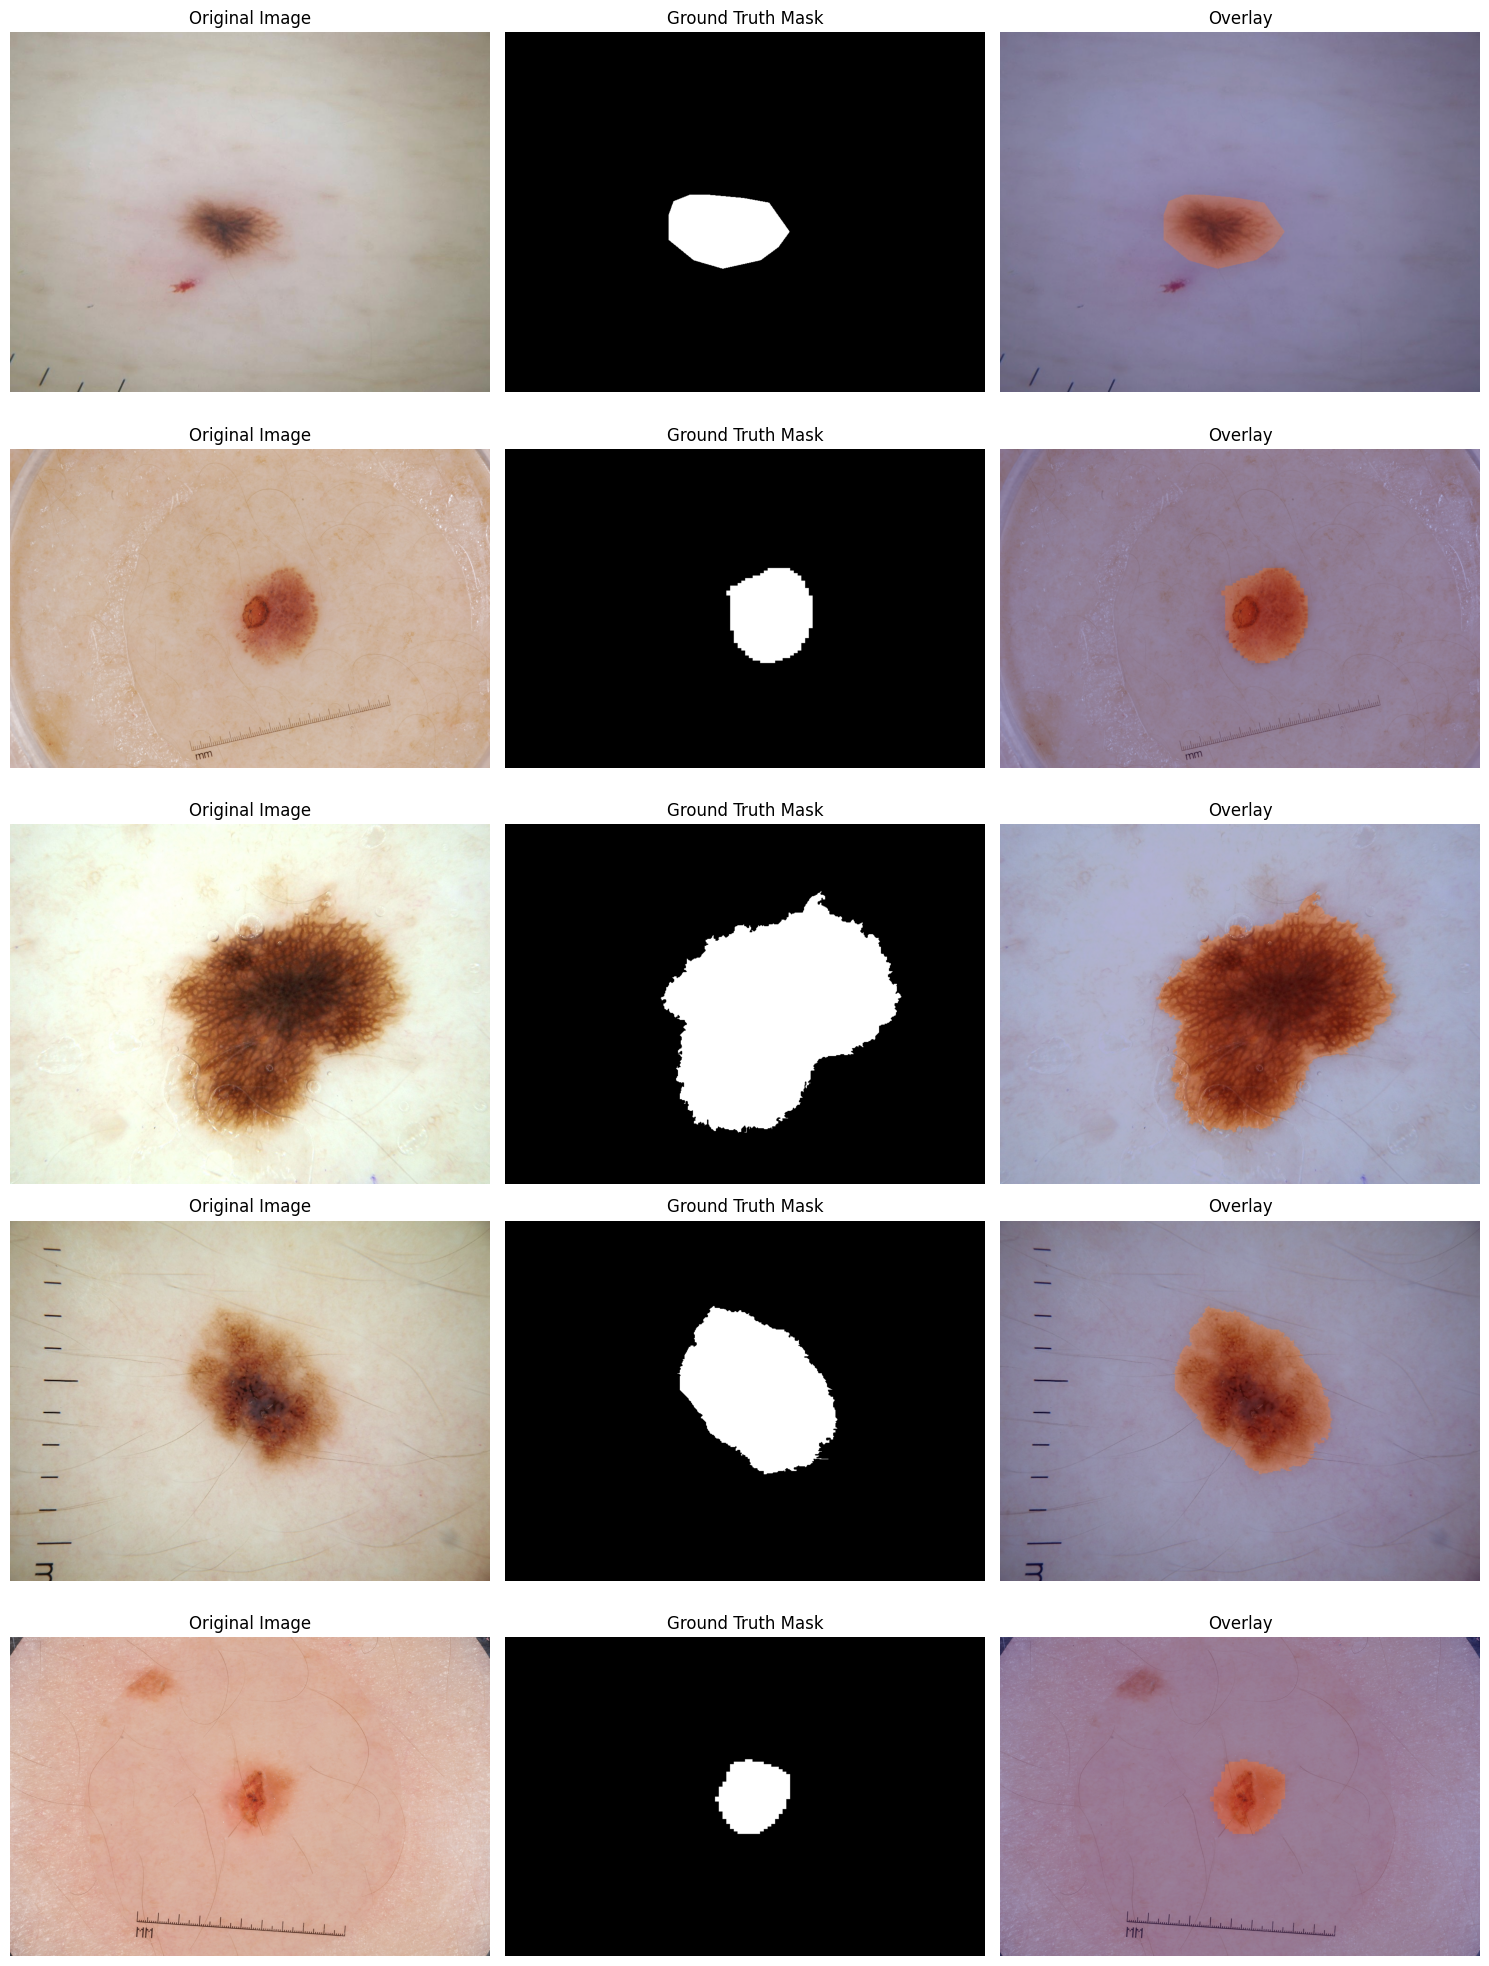

✅ EDA visualization saved!


In [4]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================

# Adjust these paths based on your downloaded folder structure
# Run !ls /content/data/ first to see what folders exist
IMAGE_DIR = "/content/data/images_extracted/ISIC2018_Task1-2_Training_Input/"
MASK_DIR  = "/content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/"

# Get sorted file lists
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"Total Images: {len(image_paths)}")
print(f"Total Masks:  {len(mask_paths)}")
print(f"Sample Image: {image_paths[0]}")
print(f"Sample Mask:  {mask_paths[0]}")

# Visualize 5 samples
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for i in range(5):
    idx = np.random.randint(0, len(image_paths))
    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)
    overlay = cv2.addWeighted(img, 0.7,
                cv2.cvtColor(cv2.applyColorMap(
                    (mask > 127).astype(np.uint8) * 255,
                    cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB), 0.3, 0)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualization saved!")

In [5]:
# ============================================================
# CELL 4: DATA LOADING & AUGMENTATION PIPELINE
# CRITICAL: Same augmentation applied to BOTH image and mask!
# ============================================================

!pip install -q albumentations

import albumentations as A

def load_and_preprocess(image_path, mask_path):
    """Load image and mask, resize to target dimensions"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img.astype(np.float32) / 255.0  # Normalize to [0, 1]

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = (mask > 127).astype(np.float32)  # Binary: 0 or 1
    mask = np.expand_dims(mask, axis=-1)    # Add channel dim: (256, 256, 1)

    return img, mask

# Augmentation pipeline (applied identically to image + mask)
train_augmentation = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=25,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=1.0),
    ], p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
], additional_targets={'mask': 'mask'})

val_augmentation = A.Compose([
    # No augmentation for validation — just clean resize
], additional_targets={'mask': 'mask'})

def augment_data(image, mask, augmentation):
    """Apply augmentation to image-mask pair"""
    augmented = augmentation(image=image, mask=mask)
    return augmented['image'], augmented['mask']

# Split data: 70% train, 15% val, 15% test
X_train_paths, X_temp_paths, y_train_paths, y_temp_paths = train_test_split(
    image_paths, mask_paths, test_size=0.30, random_state=SEED
)
X_val_paths, X_test_paths, y_val_paths, y_test_paths = train_test_split(
    X_temp_paths, y_temp_paths, test_size=0.50, random_state=SEED
)

print(f"Training:   {len(X_train_paths)} images")
print(f"Validation: {len(X_val_paths)} images")
print(f"Test:       {len(X_test_paths)} images")

# Create tf.data pipeline
def create_dataset(img_paths, msk_paths, augmentation, batch_size, shuffle=True):
    """Create efficient tf.data.Dataset pipeline"""

    def generator():
        for img_path, msk_path in zip(img_paths, msk_paths):
            img, mask = load_and_preprocess(img_path, msk_path)
            if augmentation:
                img, mask = augment_data(img, mask, augmentation)
            yield img, mask

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=tf.float32),
            tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 1), dtype=tf.float32)
        )
    )

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(img_paths))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = create_dataset(X_train_paths, y_train_paths, train_augmentation, BATCH_SIZE)
val_dataset = create_dataset(X_val_paths, y_val_paths, val_augmentation, BATCH_SIZE)
test_dataset = create_dataset(X_test_paths, y_test_paths, val_augmentation, BATCH_SIZE)

print(f"\n✅ Data pipelines created!")
print(f"Train batches: {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Val batches:   {tf.data.experimental.cardinality(val_dataset).numpy()}")

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1351/472385614.py:40: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


Training:   1815 images
Validation: 389 images
Test:       390 images

✅ Data pipelines created!
Train batches: -2
Val batches:   -2


In [6]:
# ============================================================
# CELL 5: U-Net ARCHITECTURE — BUILT COMPLETELY FROM SCRATCH
# This is what makes your GitHub impressive for Mitacs!
# ============================================================

def conv_block(inputs, num_filters, name):
    """
    Double convolution block: Conv → BN → ReLU → Conv → BN → ReLU
    The fundamental building block of U-Net
    """
    x = layers.Conv2D(num_filters, 3, padding="same",
                       kernel_initializer="he_normal",
                       name=f"{name}_conv1")(inputs)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)

    x = layers.Conv2D(num_filters, 3, padding="same",
                       kernel_initializer="he_normal",
                       name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = layers.Activation("relu", name=f"{name}_relu2")(x)
    return x

def encoder_block(inputs, num_filters, name):
    """
    Encoder block: Conv Block → MaxPool (downsample 2x)
    Returns: conv features (for skip connection) + pooled output
    """
    x = conv_block(inputs, num_filters, name)
    p = layers.MaxPooling2D(pool_size=(2, 2), name=f"{name}_pool")(x)
    return x, p

def decoder_block(inputs, skip_features, num_filters, name):
    """
    Decoder block: UpConv (upsample 2x) → Concat skip → Conv Block
    Skip connections preserve fine-grained spatial details
    """
    x = layers.Conv2DTranspose(num_filters, 2, strides=(2, 2),
                                padding="same",
                                name=f"{name}_upconv")(inputs)
    x = layers.Concatenate(name=f"{name}_concat")([x, skip_features])
    x = conv_block(x, num_filters, name)
    return x

def build_unet(input_shape=(256, 256, 3)):
    """
    Complete U-Net Architecture
    ─────────────────────────────
    Encoder (Contracting Path):
      Block 1: 64 filters  → 256×256
      Block 2: 128 filters → 128×128
      Block 3: 256 filters → 64×64
      Block 4: 512 filters → 32×32

    Bottleneck:
      1024 filters → 16×16

    Decoder (Expanding Path):
      Block 1: 512 filters → 32×32
      Block 2: 256 filters → 64×64
      Block 3: 128 filters → 128×128
      Block 4: 64 filters  → 256×256

    Output: 1 channel sigmoid → Binary mask
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    # ─── ENCODER (Contracting Path) ───
    s1, p1 = encoder_block(inputs, 64, "enc1")    # 256×256 → 128×128
    s2, p2 = encoder_block(p1, 128, "enc2")        # 128×128 → 64×64
    s3, p3 = encoder_block(p2, 256, "enc3")        # 64×64   → 32×32
    s4, p4 = encoder_block(p3, 512, "enc4")        # 32×32   → 16×16

    # ─── BOTTLENECK ───
    b = conv_block(p4, 1024, "bottleneck")          # 16×16 (deepest features)

    # ─── DECODER (Expanding Path) ───
    d1 = decoder_block(b, s4, 512, "dec1")          # 16×16   → 32×32
    d2 = decoder_block(d1, s3, 256, "dec2")         # 32×32   → 64×64
    d3 = decoder_block(d2, s2, 128, "dec3")         # 64×64   → 128×128
    d4 = decoder_block(d3, s1, 64, "dec4")          # 128×128 → 256×256

    # ─── OUTPUT ───
    outputs = layers.Conv2D(1, 1, activation="sigmoid",
                            name="output_mask")(d4)

    model = Model(inputs=inputs, outputs=outputs, name="U-Net")
    return model

# Build and display
unet_model = build_unet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
unet_model.summary()

# Count parameters
total_params = unet_model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")
print(f"📊 Model Size: ~{total_params * 4 / (1024**2):.1f} MB (float32)")

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 256, 256,  │      1,792 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 256, 256,  │        256 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 256, 256,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv2 (Conv2D) │ (None, 256, 256,  │     36,928 │ enc1_relu1[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 256, 256,  │        256 │ enc1_conv2[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu2          │ (None, 256, 256,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_pool           │ (None, 128, 128,  │          0 │ enc1_relu2[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv1 (Conv2D) │ (None, 128, 128,  │     73,856 │ enc1_pool[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 128, 128,  │        512 │ enc2_conv1[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu1          │ (None, 128, 128,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_conv2 (Conv2D) │ (None, 128, 128,  │    147,584 │ enc2_relu1[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 128, 128,  │        512 │ enc2_conv2[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_relu2          │ (None, 128, 128,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_pool           │ (None, 64, 64,    │          0 │ enc2_relu2[0][0]  │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_conv1 (Conv2D) │ (None, 64, 64,    │    295,168 │ enc2_pool[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 64, 64,    │      1,024 │ enc3_conv1[0][0]

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)


📊 Total Parameters: 31,055,297
📊 Model Size: ~118.5 MB (float32)


In [7]:
# ============================================================
# CELL 6: CUSTOM LOSS FUNCTIONS & METRICS
# Medical segmentation needs specialized losses!
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice Coefficient: Measures overlap between prediction and ground truth
    Formula: 2 * |A ∩ B| / (|A| + |B|)
    Range: 0 (no overlap) to 1 (perfect overlap)
    """
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    """Dice Loss = 1 - Dice Coefficient (we minimize this)"""
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    """
    Combined Loss: Binary Cross-Entropy + Dice Loss
    - BCE: Good for pixel-level classification
    - Dice: Good for handling class imbalance (lesion vs background)
    - Combined: Best of both worlds (standard in medical imaging)
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    """
    Intersection over Union (Jaccard Index)
    Formula: |A ∩ B| / |A ∪ B|
    More strict than Dice — penalizes false positives more
    """
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print("✅ Custom losses and metrics defined!")
print("  → bce_dice_loss: Combined BCE + Dice (primary)")
print("  → dice_coefficient: Overlap metric")
print("  → iou_metric: Jaccard index")

✅ Custom losses and metrics defined!
  → bce_dice_loss: Combined BCE + Dice (primary)
  → dice_coefficient: Overlap metric
  → iou_metric: Jaccard index


In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# Medical Image Segmentation - U-Net Baseline
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import cv2
from glob import glob
from sklearn.model_selection import train_test_split
import albumentations as A
import time

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# CELL 2: DOWNLOAD ISIC 2018 SEGMENTATION DATASET
# ============================================================

# OPTION A: Download from Kaggle (EASIEST in Colab)
# Step 1: Upload your kaggle.json file
#   → Go to kaggle.com → Settings → API → Create New Token
#   → Upload the downloaded kaggle.json to Colab

from google.colab import files
print("Upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 2: Download the dataset
!kaggle datasets download -d tschandl/isic2018 -p /content/data --unzip

# If the above dataset slug doesn't work, use this alternative:
# !kaggle datasets download -d balraj98/isic-2018-skin-lesion-segmentation -p /content/data --unzip

print("\n✅ Dataset downloaded!")
!ls /content/data/

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata

✅ Dataset downloaded!
ls: cannot access '/content/data/': No such file or directory


In [3]:
# ============================================================
# CELL 4 (OPTIMIZED): FAST IN-MEMORY DATA LOADING
# Loads images into RAM for lightning-fast GPU training!
# ============================================================
from tqdm import tqdm

def load_dataset_to_ram(img_paths, msk_paths):
    X = []
    y = []
    print(f"⚡ Pre-loading {len(img_paths)} images into RAM...")
    for img_p, msk_p in tqdm(zip(img_paths, msk_paths), total=len(img_paths)):
        # Load and resize image
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img.astype(np.float32) / 255.0

        # Load and resize mask
        mask = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        X.append(img)
        y.append(mask)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Split paths
X_train_paths, X_temp_paths, y_train_paths, y_temp_paths = train_test_split(
    image_paths, mask_paths, test_size=0.30, random_state=SEED
)
X_val_paths, X_test_paths, y_val_paths, y_test_paths = train_test_split(
    X_temp_paths, y_temp_paths, test_size=0.50, random_state=SEED
)

# Load into RAM (takes ~20 seconds total)
X_train, y_train = load_dataset_to_ram(X_train_paths, y_train_paths)
X_val, y_val     = load_dataset_to_ram(X_val_paths, y_val_paths)
X_test, y_test   = load_dataset_to_ram(X_test_paths, y_test_paths)

print(f"\n✅ Data in RAM!")
print(f"X_train shape: {X_train.shape} ({X_train.nbytes / 1e6:.1f} MB)")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

NameError: name 'image_paths' is not defined

In [4]:
# ============================================================
# CELL 1: SETUP, GPU CHECK & CONFIGURATION
# Medical Image Segmentation - U-Net Baseline
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Print Environment Info
print("=" * 60)
print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU DETECTED: {gpus[0].name}")
else:
    print("❌ NO GPU DETECTED! Please change Runtime to T4 GPU.")
print("=" * 60)

# Global Configuration
SEED = 42
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 1e-4

np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow Version: 2.20.0
✅ GPU DETECTED: /physical_device:GPU:0


In [5]:
# ============================================================
# CELL 2: DIRECT PUBLIC DATASET DOWNLOAD
# Downloads ISIC 2018 directly from official S3 storage
# ============================================================

print("⏳ Creating directories...")
!mkdir -p /content/data/images
!mkdir -p /content/data/masks

print("\n🚀 Downloading ISIC 2018 Images (~2.5 GB)...")
!wget -q --show-progress -O /content/data/images.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip"

print("\n🚀 Downloading ISIC 2018 Ground Truth Masks (~27 MB)...")
!wget -q --show-progress -O /content/data/masks.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip"

print("\n📦 Unzipping dataset...")
!unzip -q /content/data/images.zip -d /content/data/images_extracted/
!unzip -q /content/data/masks.zip -d /content/data/masks_extracted/

# Clean up zip archives to save disk space
!rm /content/data/images.zip /content/data/masks.zip

print("\n✅ DATASET DOWNLOADED & EXTRACTED SUCCESSFULLY!")

⏳ Creating directories...

🚀 Downloading ISIC 2018 Images (~2.5 GB)...
/content/data/image 100%[===================>]  10.40G  45.5MB/s    in 6m 35s  

🚀 Downloading ISIC 2018 Ground Truth Masks (~27 MB)...
/content/data/masks 100%[===================>]  26.13M  28.5MB/s    in 0.9s    

📦 Unzipping dataset...

✅ DATASET DOWNLOADED & EXTRACTED SUCCESSFULLY!


In [1]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

IMAGE_DIR = "/content/data/images_extracted/ISIC2018_Task1-2_Training_Input/"
MASK_DIR  = "/content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/"

# Retrieve sorted file paths
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths  = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"Total Images Found: {len(image_paths)}")
print(f"Total Masks Found:  {len(mask_paths)}")
assert len(image_paths) == len(mask_paths), "Mismatch between images and masks count!"

# Verify alignment
print(f"Sample Image Path: {os.path.basename(image_paths[0])}")
print(f"Sample Mask Path:  {os.path.basename(mask_paths[0])}")

# Visualize 4 random pairs
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for i in range(4):
    idx = np.random.randint(0, len(image_paths))

    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

    # Resize for display overlay
    img_disp = cv2.resize(img, (256, 256))
    mask_disp = cv2.resize(mask, (256, 256))

    # Green mask overlay
    overlay = img_disp.copy()
    overlay[mask_disp > 127] = overlay[mask_disp > 127] * 0.5 + np.array([0, 255, 0]) * 0.5

    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f"Image: {os.path.basename(image_paths[idx])[:12]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_disp, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay Ground Truth", fontsize=9)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualization complete!")

NameError: name 'glob' is not defined

In [2]:
# ============================================================
# CELL 1: SETUP, GPU CHECK & CONFIGURATION
# Medical Image Segmentation - U-Net Baseline
# Author: Mahnoor | ISIC 2018 Skin Lesion Segmentation
# ============================================================

import os
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Print Environment Info
print("=" * 60)
print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU DETECTED: {gpus[0].name}")
else:
    print("❌ NO GPU DETECTED! Please change Runtime to T4 GPU.")
print("=" * 60)

# Global Configuration
SEED = 42
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 1e-4

np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow Version: 2.20.0
✅ GPU DETECTED: /physical_device:GPU:0


In [3]:
# ============================================================
# CELL 2: DIRECT PUBLIC DATASET DOWNLOAD
# Downloads ISIC 2018 directly from official S3 storage
# ============================================================

print("⏳ Creating directories...")
!mkdir -p /content/data/images
!mkdir -p /content/data/masks

print("\n🚀 Downloading ISIC 2018 Images (~2.5 GB)...")
!wget -q --show-progress -O /content/data/images.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1-2_Training_Input.zip"

print("\n🚀 Downloading ISIC 2018 Ground Truth Masks (~27 MB)...")
!wget -q --show-progress -O /content/data/masks.zip \
    "https://isic-challenge-data.s3.amazonaws.com/2018/ISIC2018_Task1_Training_GroundTruth.zip"

print("\n📦 Unzipping dataset...")
!unzip -q /content/data/images.zip -d /content/data/images_extracted/
!unzip -q /content/data/masks.zip -d /content/data/masks_extracted/

# Clean up zip archives to save disk space
!rm /content/data/images.zip /content/data/masks.zip

print("\n✅ DATASET DOWNLOADED & EXTRACTED SUCCESSFULLY!")

⏳ Creating directories...

🚀 Downloading ISIC 2018 Images (~2.5 GB)...
/content/data/image 100%[===================>]  10.40G  42.4MB/s    in 4m 10s  

🚀 Downloading ISIC 2018 Ground Truth Masks (~27 MB)...
/content/data/masks 100%[===================>]  26.13M  31.9MB/s    in 0.8s    

📦 Unzipping dataset...

✅ DATASET DOWNLOADED & EXTRACTED SUCCESSFULLY!


Total Images Found: 2594
Total Masks Found:  2594
Sample Image Path: ISIC_0000000.jpg
Sample Mask Path:  ISIC_0000000_segmentation.png


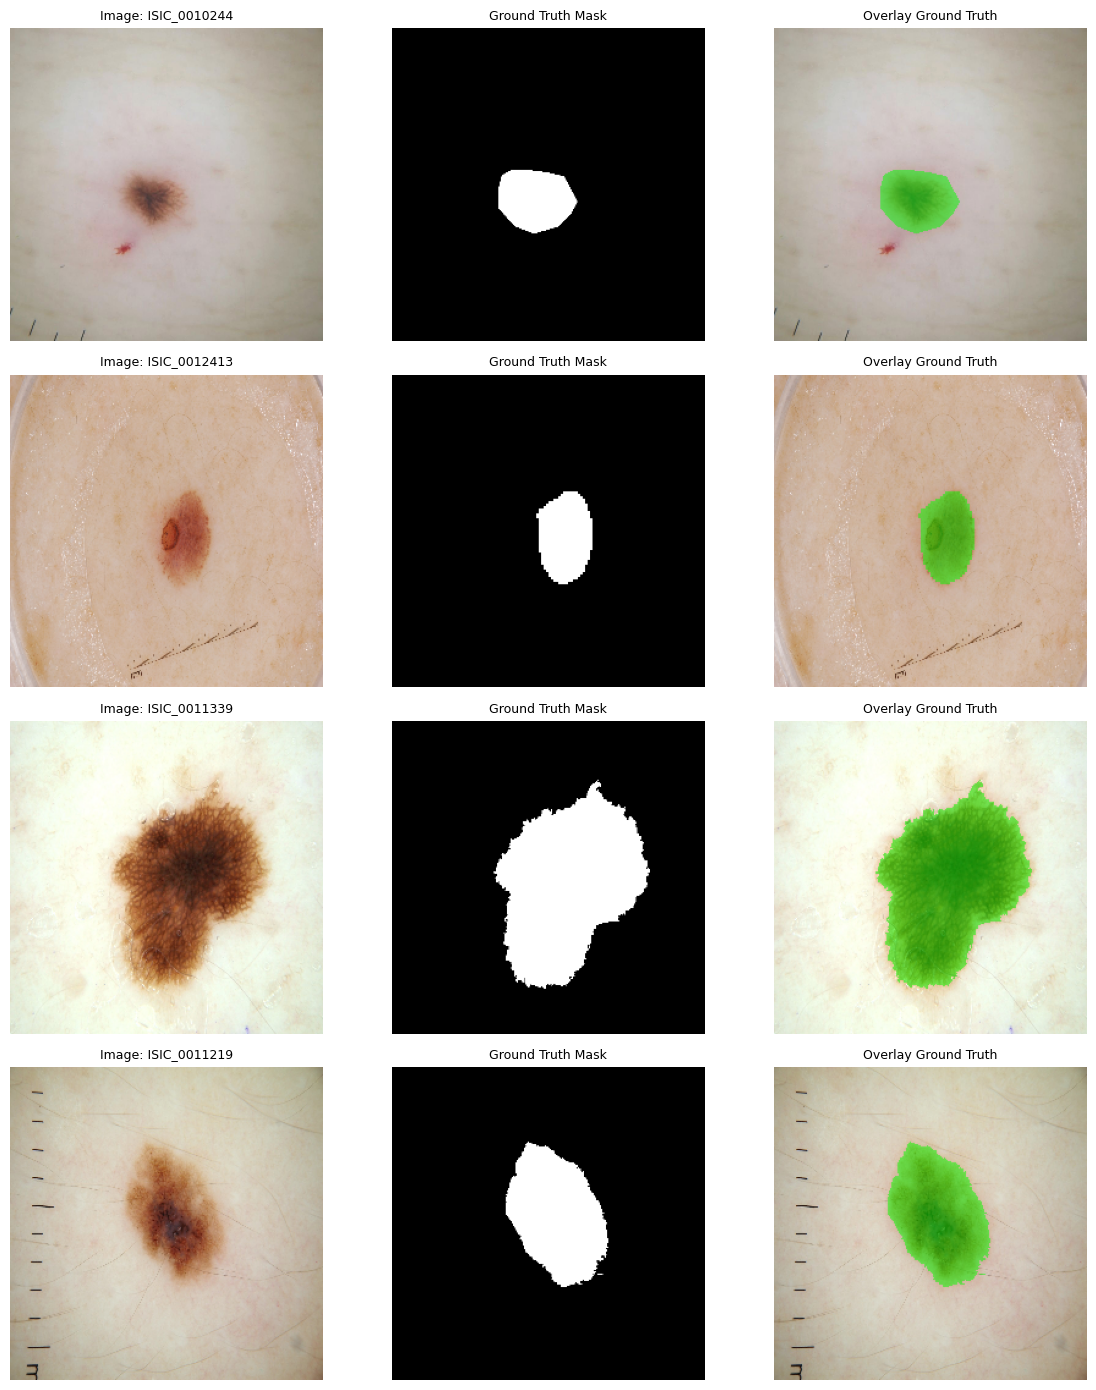

✅ EDA visualization complete!


In [4]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

IMAGE_DIR = "/content/data/images_extracted/ISIC2018_Task1-2_Training_Input/"
MASK_DIR  = "/content/data/masks_extracted/ISIC2018_Task1_Training_GroundTruth/"

# Retrieve sorted file paths
image_paths = sorted(glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths  = sorted(glob(os.path.join(MASK_DIR, "*.png")))

print(f"Total Images Found: {len(image_paths)}")
print(f"Total Masks Found:  {len(mask_paths)}")
assert len(image_paths) == len(mask_paths), "Mismatch between images and masks count!"

# Verify alignment
print(f"Sample Image Path: {os.path.basename(image_paths[0])}")
print(f"Sample Mask Path:  {os.path.basename(mask_paths[0])}")

# Visualize 4 random pairs
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
for i in range(4):
    idx = np.random.randint(0, len(image_paths))

    img = cv2.imread(image_paths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

    # Resize for display overlay
    img_disp = cv2.resize(img, (256, 256))
    mask_disp = cv2.resize(mask, (256, 256))

    # Green mask overlay
    overlay = img_disp.copy()
    overlay[mask_disp > 127] = overlay[mask_disp > 127] * 0.5 + np.array([0, 255, 0]) * 0.5

    axes[i, 0].imshow(img_disp)
    axes[i, 0].set_title(f"Image: {os.path.basename(image_paths[idx])[:12]}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_disp, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay Ground Truth", fontsize=9)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("eda_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA visualization complete!")

In [5]:
# ============================================================
# CELL 4: FAST IN-MEMORY DATA LOADING
# Pre-loads dataset into GPU RAM (~2 GB total)
# ============================================================

def load_data_to_ram(img_paths, msk_paths):
    X = []
    y = []
    print(f"⚡ Pre-loading {len(img_paths)} images into RAM...")
    for img_p, msk_p in tqdm(zip(img_paths, msk_paths), total=len(img_paths)):
        # Image preprocessing
        img = cv2.imread(img_p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img.astype(np.float32) / 255.0

        # Mask preprocessing
        mask = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=-1)

        X.append(img)
        y.append(mask)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Train (70%), Validation (15%), Test (15%) Split
X_train_paths, X_temp_paths, y_train_paths, y_temp_paths = train_test_split(
    image_paths, mask_paths, test_size=0.30, random_state=SEED
)
X_val_paths, X_test_paths, y_val_paths, y_test_paths = train_test_split(
    X_temp_paths, y_temp_paths, test_size=0.50, random_state=SEED
)

# Execute fast load
X_train, y_train = load_data_to_ram(X_train_paths, y_train_paths)
X_val, y_val     = load_data_to_ram(X_val_paths, y_val_paths)
X_test, y_test   = load_data_to_ram(X_test_paths, y_test_paths)

print("\n✅ All data loaded into RAM successfully!")
print(f"   Training set:   {X_train.shape} | Mask: {y_train.shape}")
print(f"   Validation set: {X_val.shape}   | Mask: {y_val.shape}")
print(f"   Test set:       {X_test.shape}  | Mask: {y_test.shape}")

⚡ Pre-loading 1815 images into RAM...


100%|██████████| 1815/1815 [04:30<00:00,  6.70it/s]


⚡ Pre-loading 389 images into RAM...


100%|██████████| 389/389 [01:02<00:00,  6.26it/s]


⚡ Pre-loading 390 images into RAM...


100%|██████████| 390/390 [00:58<00:00,  6.65it/s]



✅ All data loaded into RAM successfully!
   Training set:   (1815, 256, 256, 3) | Mask: (1815, 256, 256, 1)
   Validation set: (389, 256, 256, 3)   | Mask: (389, 256, 256, 1)
   Test set:       (390, 256, 256, 3)  | Mask: (390, 256, 256, 1)


In [6]:
# ============================================================
# CELL 5: U-Net ARCHITECTURE FROM SCRATCH
# Encoder-Decoder network with Skip Connections
# ============================================================

def conv_block(inputs, num_filters, block_name):
    """Conv2D -> BN -> ReLU -> Conv2D -> BN -> ReLU"""
    x = layers.Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal", name=f"{block_name}_conv1")(inputs)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.Activation("relu", name=f"{block_name}_relu1")(x)

    x = layers.Conv2D(num_filters, 3, padding="same", kernel_initializer="he_normal", name=f"{block_name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.Activation("relu", name=f"{block_name}_relu2")(x)
    return x

def encoder_block(inputs, num_filters, block_name):
    """Conv Block followed by 2x2 Max Pooling"""
    skip = conv_block(inputs, num_filters, block_name)
    pool = layers.MaxPooling2D(pool_size=(2, 2), name=f"{block_name}_pool")(skip)
    return skip, pool

def decoder_block(inputs, skip_features, num_filters, block_name):
    """2x2 ConvTranspose -> Concatenate Skip Features -> Conv Block"""
    x = layers.Conv2DTranspose(num_filters, 2, strides=(2, 2), padding="same", name=f"{block_name}_upconv")(inputs)
    x = layers.Concatenate(name=f"{block_name}_concat")([x, skip_features])
    x = conv_block(x, num_filters, block_name)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape, name="input_image")

    # ─── ENCODER (Contracting Path) ───
    s1, p1 = encoder_block(inputs, 64, "enc1")     # 256 -> 128
    s2, p2 = encoder_block(p1, 128, "enc2")        # 128 -> 64
    s3, p3 = encoder_block(p2, 256, "enc3")        # 64  -> 32
    s4, p4 = encoder_block(p3, 512, "enc4")        # 32  -> 16

    # ─── BOTTLENECK ───
    b1 = conv_block(p4, 1024, "bottleneck")        # 16x16 representation

    # ─── DECODER (Expanding Path) ───
    d1 = decoder_block(b1, s4, 512, "dec1")        # 16  -> 32
    d2 = decoder_block(d1, s3, 256, "dec2")        # 32  -> 64
    d3 = decoder_block(d2, s2, 128, "dec3")        # 64  -> 128
    d4 = decoder_block(d3, s1, 64, "dec4")         # 128 -> 256

    # ─── OUTPUT LAYER ───
    outputs = layers.Conv2D(1, 1, activation="sigmoid", name="output_mask")(d4)

    model = Model(inputs=inputs, outputs=outputs, name="U-Net_Scratch")
    return model

unet_model = build_unet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
print(f"✅ U-Net compiled successfully! Total Parameters: {unet_model.count_params():,}")

✅ U-Net compiled successfully! Total Parameters: 31,055,297


In [7]:
# ============================================================
# CELL 6: MEDICAL LOSS FUNCTIONS & EVALUATION METRICS
# Combined Binary Cross-Entropy + Dice Loss
# ============================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Measures spatial overlap between prediction and target [0 to 1]"""
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    """Combines BCE (pixel-level accuracy) + Dice (handles target size imbalance)"""
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    """Intersection over Union (Jaccard Index)"""
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

print("✅ Loss functions and metrics prepared!")

✅ Loss functions and metrics prepared!


In [ ]:
# ============================================================
# CELL 7: GPU TRAINING LOOP
# Expected time: ~15-25 seconds per epoch on T4 GPU
# ============================================================

unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric]
)

callbacks = [
    EarlyStopping(monitor="val_dice_coefficient", patience=10, mode="max", restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_unet_isic2018.keras", monitor="val_dice_coefficient", mode="max", save_best_only=True, verbose=1)
]

print("🚀 Starting Training on GPU...")
start_time = time.time()

history = unet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start_time
print(f"\n🎉 TRAINING COMPLETED IN {elapsed/60:.2f} MINUTES!")

🚀 Starting Training on GPU...
Epoch 1/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - dice_coefficient: 0.5250 - iou_metric: 0.3653 - loss: 0.8769   
Epoch 1: val_dice_coefficient improved from None to 0.51681, saving model to best_unet_isic2018.keras

Epoch 1: finished saving model to best_unet_isic2018.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - dice_coefficient: 0.6146 - iou_metric: 0.4526 - loss: 0.7179 - val_dice_coefficient: 0.5168 - val_iou_metric: 0.3508 - val_loss: 1.8076 - learning_rate: 1.0000e-04
Epoch 2/40
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - dice_coefficient: 0.7192 - iou_metric: 0.5645 - loss: 0.5111
Epoch 2: val_dice_coefficient improved from 0.51681 to 0.71828, saving model to best_unet_isic2018.keras

Epoch 2: finished saving model to best_unet_isic2018.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 108s 944ms/step - dice_coefficient: 0.7412 - iou_metric: 0.5922 - loss: 0.4798 - val_dice_coefficient: 0.7183 - val_iou_metric: 0.5623 - val_loss: 0.6950 - learning_rate: 1